# Scalings
P(s) curves for sister-specific G2 data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
plt.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42})
sns.set_context('talk')

## Load data
Aggregated scalings and derivatives.

In [3]:
repo = Path('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/scalings/')
records = dict()
for cond in ('WT_G2', 'dCTCF_G2', 'dNIPBL_G2', 'dWAPL_G2'):
    record = {'cond': cond}
    for sis in ('cis', 'trans'):
        record[f"{sis}_agg_scaling"] = pd.read_parquet(repo / cond / f"{cond}.{sis}.agg_scaling.parquet")
        record[f"{sis}_derivative"] = pd.read_parquet(repo / cond / f"{cond}.{sis}.derivative.parquet")
    records[cond] = record

## Normalize scalings

Normalize scaling so that the sum of areas under curves for cis and trans equals 1 in the range of 10Kb...200Mb.

In [4]:
def auc_norm_factor(min_dists, max_dists, freqs, norm_range):
    mid_dists = np.sqrt(min_dists * max_dists)
    dist_mask = (mid_dists > norm_range[0]) & (mid_dists < norm_range[1])
    dist_diff = max_dists - min_dists
    _dist_diff = dist_diff[dist_mask]
    _freqs = freqs[dist_mask]
    norm_factor = np.sum(_dist_diff.values * _freqs.values)
    return norm_factor

In [5]:
def normalize_jointly(record, norm_range, label="{sis}_auc_joint", cis_only=False):
    cis_data = record['cis_agg_scaling']
    trans_data = record['trans_agg_scaling']
    factor_cis = auc_norm_factor(cis_data['min_dist'], cis_data['max_dist'], cis_data['freq'], norm_range)
    if cis_only:
        norm_factor = factor_cis
    else:
        factor_trans = auc_norm_factor(trans_data['min_dist'], trans_data['max_dist'], trans_data['freq'], norm_range)
        norm_factor = factor_cis + factor_trans
    
    cis_norm_data = cis_data.assign(freq=lambda df: df['freq'] / norm_factor)
    trans_norm_data = trans_data.assign(freq=lambda df: df['freq'] / norm_factor)
    record[label.format(sis='cis')] = cis_norm_data
    record[label.format(sis='trans')] = trans_norm_data

In [6]:
for record in records.values():
    normalize_jointly(record, (1e4, 2e8), label="{sis}_joint_10Kb_200Mb")

/srv/conda/envs/notebook/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Figure S3K: Plot WT vs dCTCF

In [7]:
def plot_scaling_curve(scaling_data, **kwargs):
    dists = scaling_data.query('mask')['dist']
    freqs = scaling_data.query('mask')['freq']
    plt.loglog(dists, freqs, **kwargs)

In [8]:
def plot_cis_and_trans(record_1, record_2, label="{sis}_auc_joint", names=('1', '2'), xlims=None, ylims=None, **subplots_kws):
    fig, axes = plt.subplots(1, 2, **subplots_kws)
    name_1, name_2 = names
    
    for i, sis in enumerate(('cis', 'trans')):
        plt.sca(axes[i])
        plot_scaling_curve(record_1[label.format(sis=sis)],
                           ls='-',
                           color='.5',
                           label=name_1,
                           zorder=3)
        plot_scaling_curve(record_2[label.format(sis=sis)],
                           ls='-',
                           color='k',
                           label=name_2,
                           zorder=3)
        plt.xticks(10 ** np.arange(0, 10))
        plt.xlim(*xlims)
        plt.ylim(*ylims)
        plt.xlabel('Genomic separation, bp')
        plt.ylabel('Normalized contact frequency')
        plt.title(f'{sis.capitalize()}-sister contacts')
        plt.legend()
        plt.gca().set_aspect(1.0)
        plt.grid(ls=':', color='.8', zorder=0)
    return fig, axes

### Sisters on one plot

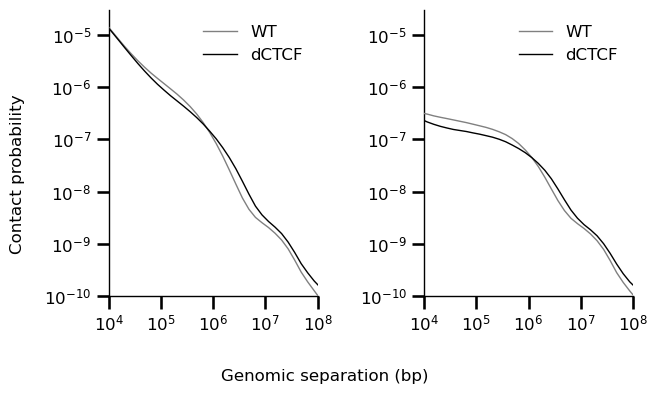

In [28]:
label = "{sis}_joint_10Kb_200Mb"
xlims = (1e4, 1e8)
ylims = (1e-10, 3e-5)
fig, axes = plot_cis_and_trans(records['WT_G2'], records['dCTCF_G2'], label=label, names=('WT', 'dCTCF'), xlims=xlims, ylims=ylims, figsize=(7, 7), width_ratios=(5, 5), sharey='row')
for ax in axes:
    ax.set_title(None)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.tick_params(labelbottom=True, labelleft=True, labelsize=12)
    ax.tick_params(which='minor', bottom=False, left=False, width=1)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1)
    for line in ax.get_lines():
        line.set_linewidth(1)
    ax.legend(fontsize=12, frameon=False, loc='upper right')
    sns.despine(ax=ax)

fig.supxlabel('Genomic separation (bp)', y=0.2, fontsize=12)
fig.supylabel('Contact probability', x=0.05, fontsize=12)
fig.tight_layout()

